In [27]:
import json
from pathlib import Path
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import soundfile as sf
from IPython.display import Audio, display
import os
import tarfile

### Descargar audio

In [6]:
# carpeta
os.makedirs('data/raw', exist_ok=True)

In [8]:
# Descargar todo el dataset
!cd data/raw && \
  wget -q https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2 && \
  echo "✓ Descargado (356 MB)" && \
  tar -xjf LJSpeech-1.1.tar.bz2 && \
  echo "✓ Extraído (7 GB)"

✓ Descargado (356 MB)
✓ Extraído (7 GB)


In [9]:
lj_path = Path('data/raw/LJSpeech-1.1')

In [10]:
# Contar archivos
wav_files = sorted([f for f in os.listdir(lj_path / 'wavs') if f.endswith('.wav')])
print(f"Total de archivos de audio: {len(wav_files)}")

Total de archivos de audio: 13100


In [11]:
# Mostrar primeros
print(f"\n   Primeros 5 archivos:")
for wav in wav_files[:5]:
    file_size = os.path.getsize(lj_path / 'wavs' / wav) / 1024
    print(f"   - {wav:20} ({file_size:>7.0f} KB)")

# Leer metadata
with open(lj_path / 'metadata.csv', 'r', encoding='utf-8') as f:
    metadata_lines = f.readlines()

print(f"\n   Transcripciones en metadata.csv: {len(metadata_lines)}\n")

# Mostrar ejemplo de metadata
print("   Ejemplo de metadata:")
first_meta = metadata_lines[0].strip().split('|')
print(f"Archivo: {first_meta[0]}")
print(f"Transcripción: {first_meta[1][:60]}...")
print(f"Tipo: {first_meta[2] if len(first_meta) > 2 else 'N/A'}\n")


   Primeros 5 archivos:
   - LJ001-0001.wav       (    416 KB)
   - LJ001-0002.wav       (     82 KB)
   - LJ001-0003.wav       (    416 KB)
   - LJ001-0004.wav       (    221 KB)
   - LJ001-0005.wav       (    349 KB)

   Transcripciones en metadata.csv: 13100

   Ejemplo de metadata:
Archivo: LJ001-0001
Transcripción: Printing, in the only sense with which we are at present con...
Tipo: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition



### Analizar audios

In [12]:
durations = []
print("Analizando duración de primeros 100 archivos...\n")

for wav_file in wav_files[:100]:
    try:
        audio, sr = librosa.load(lj_path / 'wavs' / wav_file, sr=22050)
        duration = len(audio) / sr
        durations.append(duration)
    except Exception as e:
        print(f"Error con {wav_file}: {e}")

durations = np.array(durations)

print(f"Estadísticas de duración:")
print(f"Mínima: {durations.min():.2f} segundos")
print(f"Máxima: {durations.max():.2f} segundos")
print(f"Promedio: {durations.mean():.2f} segundos")
print(f"Mediana: {np.median(durations):.2f} segundos")
print(f"Total (primeros 100): {durations.sum():.2f} segundos ({durations.sum()/60:.1f} minutos)\n")

Analizando duración de primeros 100 archivos...

Estadísticas de duración:
Mínima: 1.78 segundos
Máxima: 9.95 segundos
Promedio: 6.62 segundos
Mediana: 6.91 segundos
Total (primeros 100): 662.35 segundos (11.0 minutos)



In [13]:
# Calcular duración total estimada
total_duration_est = durations.mean() * len(wav_files)
print(f"   Duración total estimada : {total_duration_est:.0f} segundos ({total_duration_est/3600:.1f} horas)\n")

   Duración total estimada : 86768 segundos (24.1 horas)



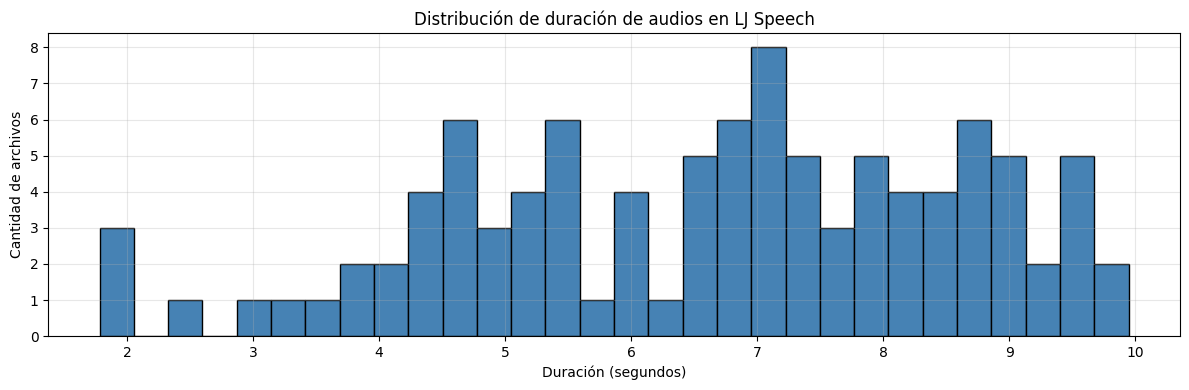

In [14]:
# Visualizar distribución
plt.figure(figsize=(12, 4))
plt.hist(durations, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Duración (segundos)')
plt.ylabel('Cantidad de archivos')
plt.title('Distribución de duración de audios en LJ Speech')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cargar un auido y explorarlo

In [15]:
# Usar primer audio
audio_file = wav_files[0]
audio_path = lj_path / 'wavs' / audio_file

print(f"Cargando audio: {audio_file}\n")

Cargando audio: LJ001-0001.wav



In [16]:
# Cargar con librosa
audio, sr = librosa.load(str(audio_path), sr=22050)

print(f"Información del audio:")
print(f"Archivo: {audio_file}")
print(f"Sample rate: {sr} Hz (22.05 kHz)")
print(f"Duración: {len(audio)/sr:.2f} segundos")
print(f"Total de muestras: {len(audio):,}")
print(f"Rango de amplitud: [{audio.min():.4f}, {audio.max():.4f}]")
print(f"RMS (energía): {np.sqrt(np.mean(audio**2)):.4f}\n")

Información del audio:
Archivo: LJ001-0001.wav
Sample rate: 22050 Hz (22.05 kHz)
Duración: 9.66 segundos
Total de muestras: 212,893
Rango de amplitud: [-0.6792, 0.8649]
RMS (energía): 0.0968



In [17]:
# Obtener transcripción
transcription = metadata_lines[0].split('|')[1]
print(f"Transcripción: {transcription}\n")

Transcripción: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition



In [18]:
# Escuchar
print("Reproduciendo audio:\n")
display(Audio(audio, rate=sr))

Reproduciendo audio:



### Visualizar forma de onda

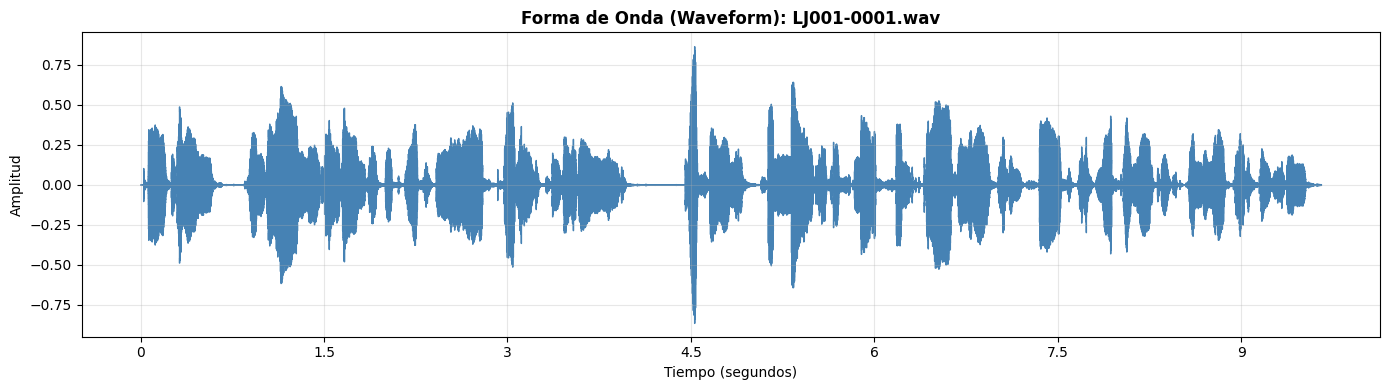

In [19]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sr, color='steelblue')
plt.title(f'Forma de Onda (Waveform): {audio_file}', fontweight='bold')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Calcular y visualizar Mel-Spectrogram

In [20]:
# Parámetros según repo oficial daniilrobnikov/vits2
n_mels = 80  # Número de bandas de mel (según VITS2)
n_fft = 1024  # FFT window size
hop_length = 256  # Hop length

# Calcular mel-spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=n_mels,
    n_fft=n_fft,
    hop_length=hop_length
)

# Convertir a dB
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print(f"Información del Mel-Spectrogram:")
print(f"Dimensiones: {mel_spec_db.shape}")
print(f"Mel bins (bandas de frecuencia): {mel_spec_db.shape[0]}")
print(f"Frames (tiempo): {mel_spec_db.shape[1]}")
print(f"Rango dinámico: {mel_spec_db.min():.1f} dB a {mel_spec_db.max():.1f} dB")
print(f"Resolución temporal: ~{hop_length/sr*1000:.1f} ms por frame\n")

Información del Mel-Spectrogram:
Dimensiones: (80, 832)
Mel bins (bandas de frecuencia): 80
Frames (tiempo): 832
Rango dinámico: -80.0 dB a 0.0 dB
Resolución temporal: ~11.6 ms por frame



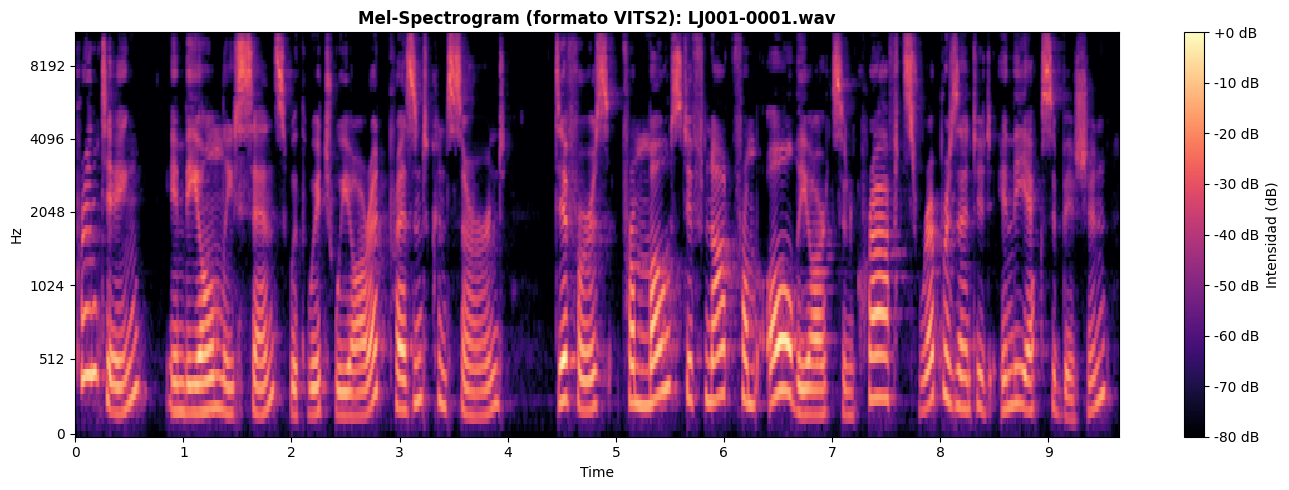

In [21]:
# Visualizar
plt.figure(figsize=(14, 5))
img = librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=hop_length,
    x_axis='time',
    y_axis='mel',
    cmap='magma'
)
plt.colorbar(img, label='Intensidad (dB)', format='%+2.0f dB')
plt.title(f'Mel-Spectrogram (formato VITS2): {audio_file}', fontweight='bold')
plt.tight_layout()
plt.show()

### Comparar diferentes representaciones

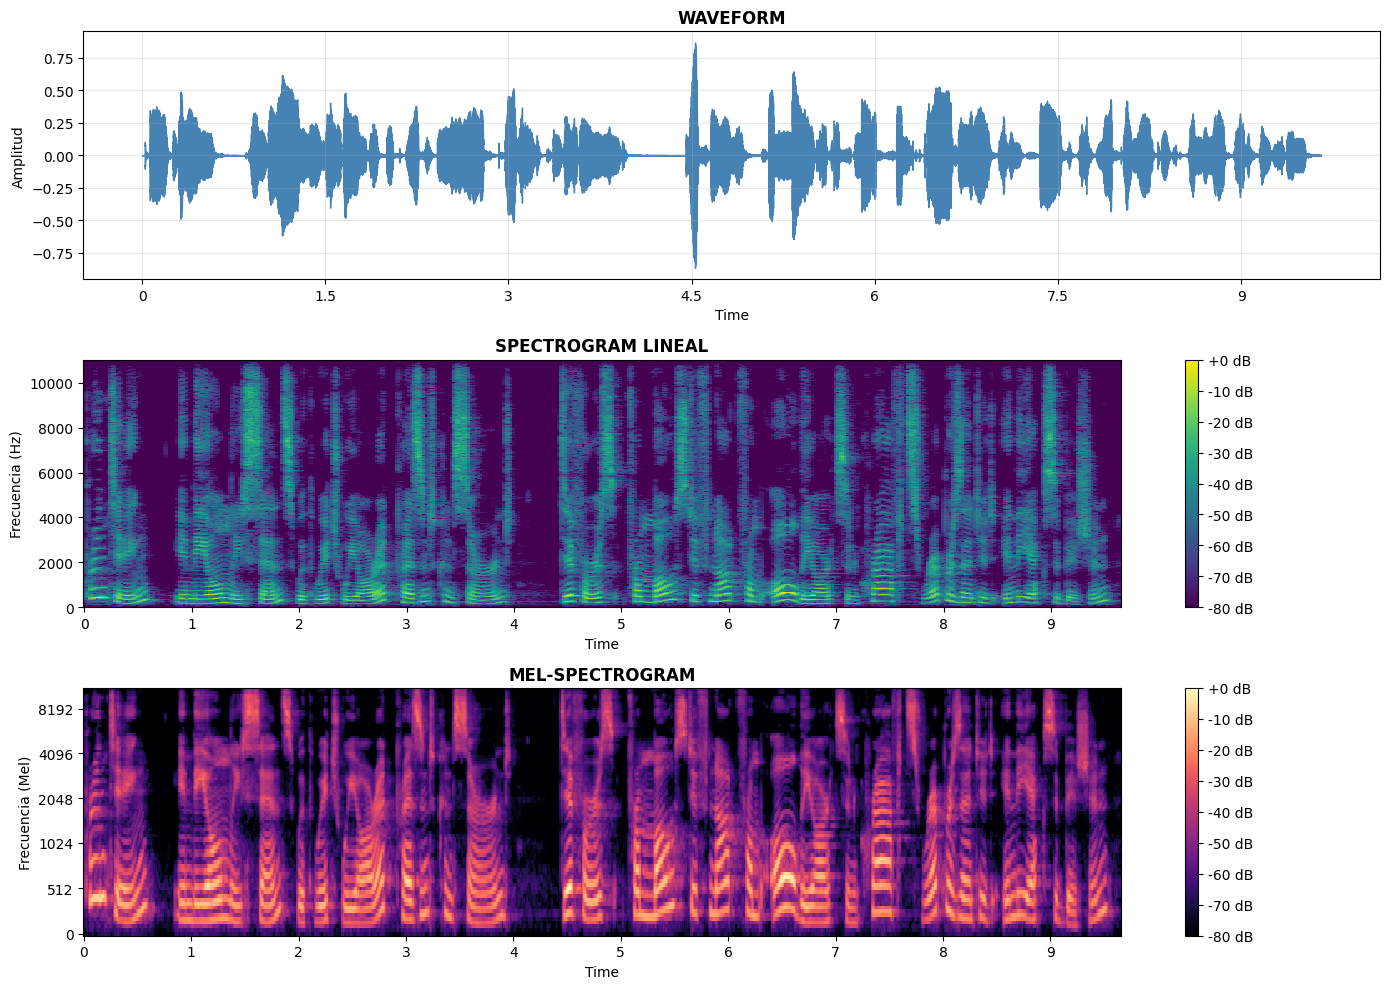

In [23]:
# Calcular spectrogram lineal
stft = librosa.stft(audio)
spectrogram_db = librosa.power_to_db(np.abs(stft)**2, ref=np.max)

# Crear figura con 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Waveform
librosa.display.waveshow(audio, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_title('WAVEFORM', fontweight='bold')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

# Spectrogram lineal
img1 = librosa.display.specshow(
    spectrogram_db, 
    sr=sr, 
    x_axis='time', 
    y_axis='linear', 
    ax=axes[1], 
    cmap='viridis'
)
axes[1].set_title('SPECTROGRAM LINEAL', fontweight='bold')
axes[1].set_ylabel('Frecuencia (Hz)')
fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')

# Mel-Spectrogram
img2 = librosa.display.specshow(
    mel_spec_db, 
    sr=sr, 
    hop_length=hop_length,
    x_axis='time', 
    y_axis='mel', 
    ax=axes[2], 
    cmap='magma'
)
axes[2].set_title('MEL-SPECTROGRAM', fontweight='bold')
axes[2].set_ylabel('Frecuencia (Mel)')
fig.colorbar(img2, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

Diferencias:
+ Waveform: Muestra presión de aire

+ Spectrogram lineal: Todas las frecuencias tienen igual importancia

+ Mel-Spectrogram: Refleja cómo el oído humano percibe el sonido

_IMPORTANTE: VITS2 entrena con MEL-SPECTROGRAMAS_

### Análisis de características

Análisis de características:
Onsets detectados: 56
Energía RMS promedio: 0.0786
Silencio detectado: 100.0%



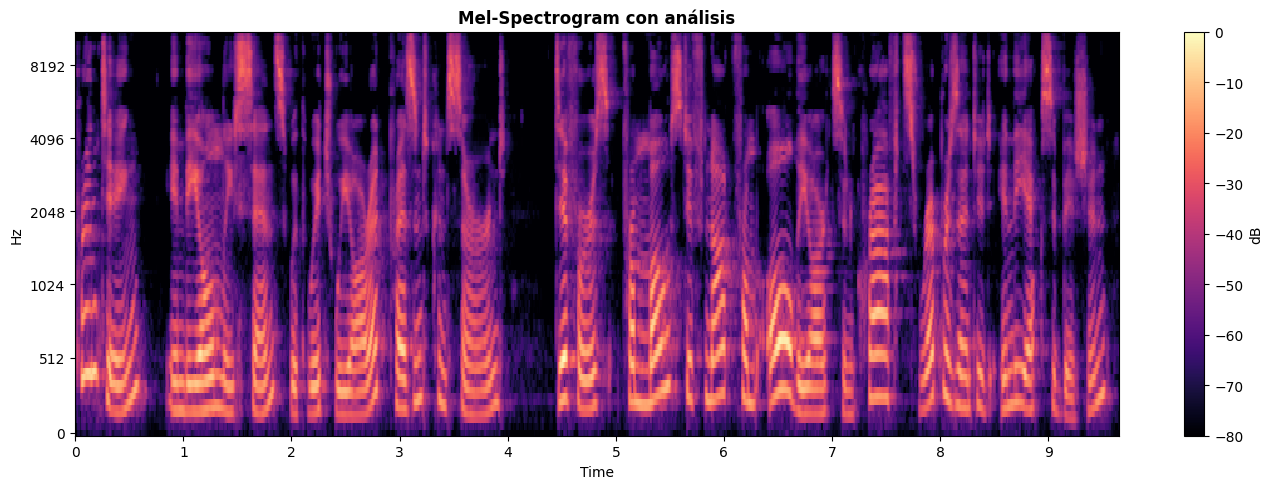

In [26]:
# Detectar onsets (inicio de sonidos)
onset_frames = librosa.onset.onset_detect(y=audio, sr=sr)
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

# Calcular energy RMS
rms_energy = librosa.feature.rms(y=audio)[0]
mean_energy = np.mean(rms_energy)

# Detectar silencio
db_threshold = -40
is_silent = (mel_spec_db.mean(axis=0) < db_threshold)
silence_percentage = np.sum(is_silent) / len(is_silent) * 100

print(f"Análisis de características:")
print(f"Onsets detectados: {len(onset_frames)}")
print(f"Energía RMS promedio: {mean_energy:.4f}")
print(f"Silencio detectado: {silence_percentage:.1f}%\n")

# Visualizar energía
fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, 
                               x_axis='time', y_axis='mel', cmap='magma', ax=ax)
ax.set_title('Mel-Spectrogram con análisis', fontweight='bold')
fig.colorbar(img, ax=ax, label='dB')
plt.tight_layout()
plt.show()